In [1]:
import pandas as pd
import numpy as np

In [7]:
#load dataset
df=pd.read_csv('Sample - Superstore.csv',encoding ='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
#shape
df.shape

(9994, 21)

In [12]:
#convert order date to datetime
df['Order Date']=pd.to_datetime(df['Order Date'])

In [15]:
df.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1839,1840,CA-2014-117345,2014-08-01,8/5/2014,Standard Class,BF-10975,Barbara Fisher,Corporate,United States,Charlotte,...,28205,South,OFF-AP-10001005,Office Supplies,Appliances,Honeywell Quietcare HEPA Air Cleaner,62.92,1,0.2,10.2245


In [17]:
#create month_year coulmn
df['Month_Year']=df['Order Date'].dt.to_period('M')

In [18]:
#**Agregate**
#group data by month year
monthly=df.groupby('Month_Year')[['Sales','Profit']].sum().reset_index()

In [20]:
#cnvt to string for plotting
monthly['Month_Year']=monthly['Month_Year'].astype(str)

In [40]:
#add profit margin
monthly['Profit Margin']=monthly['Profit']/monthly['Sales']

In [43]:
print(monthly.head())

  Month_Year      Sales     Profit  Profit Margin
0    2014-01  14236.895  2450.1907       0.172101
1    2014-02   4519.892   862.3084       0.190781
2    2014-03  55691.009   498.7299       0.008955
3    2014-04  28295.345  3488.8352       0.123301
4    2014-05  23648.287  2738.7096       0.115810


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


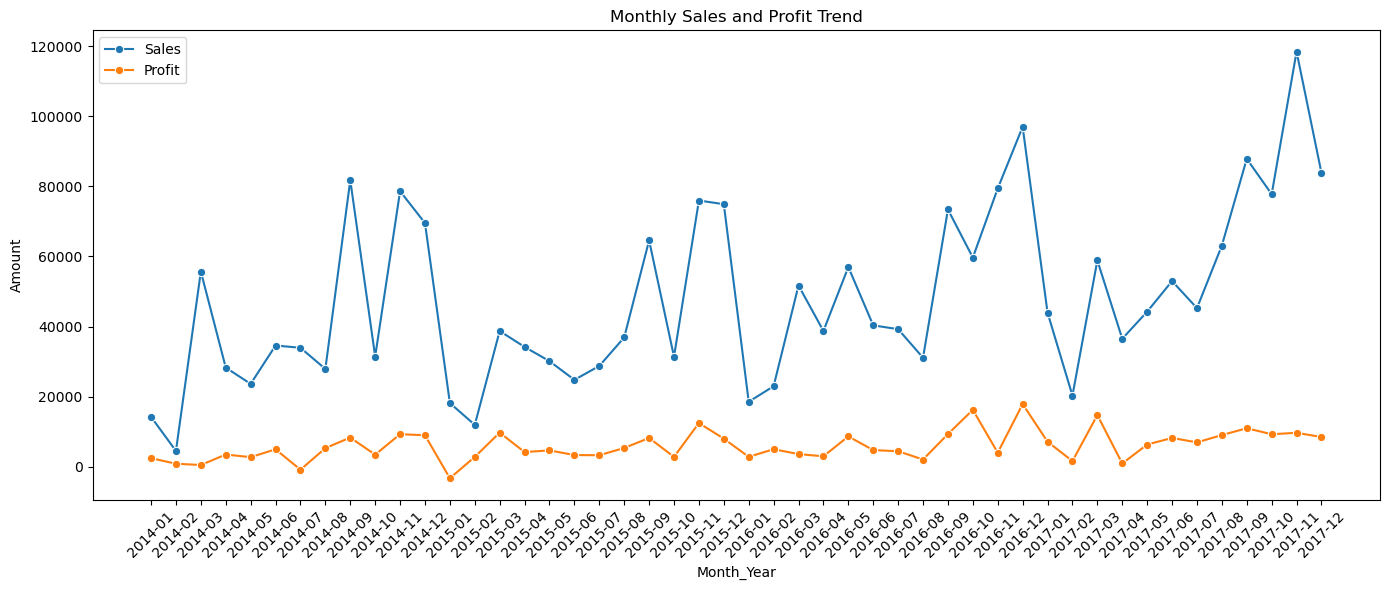

In [34]:
#visualization =sales and profit trend
plt.figure(figsize=(14,6))
sns.lineplot(x='Month_Year',y='Sales',data=monthly,marker='o',label='Sales')
sns.lineplot(x='Month_Year',y='Profit',data=monthly,marker='o',label='Profit')

plt.xticks(rotation=45)
plt.title('Monthly Sales and Profit Trend')
plt.xlabel('Month_Year')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.show()

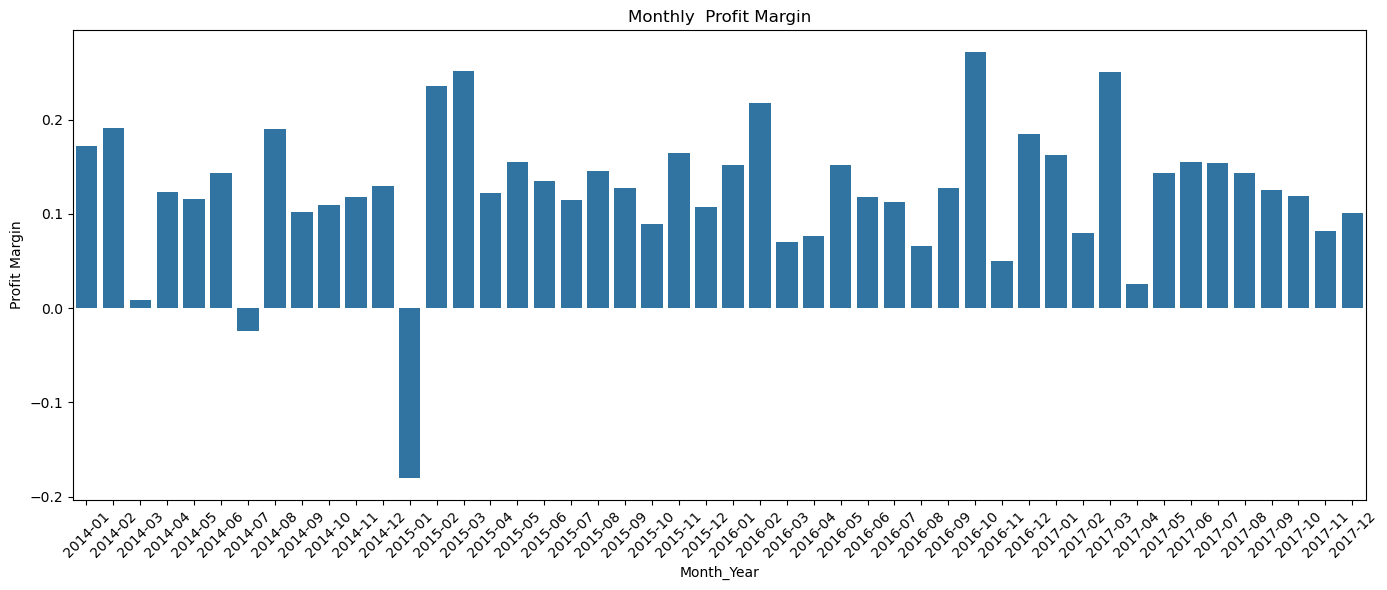

In [46]:
#visualization profit margin
plt.figure(figsize=(14,6))
sns.barplot(x='Month_Year',y='Profit Margin',data=monthly, legend='auto')

plt.xticks(rotation=45)
plt.title('Monthly  Profit Margin')
plt.xlabel('Month_Year')
plt.ylabel('Profit Margin')
plt.tight_layout()
plt.show()

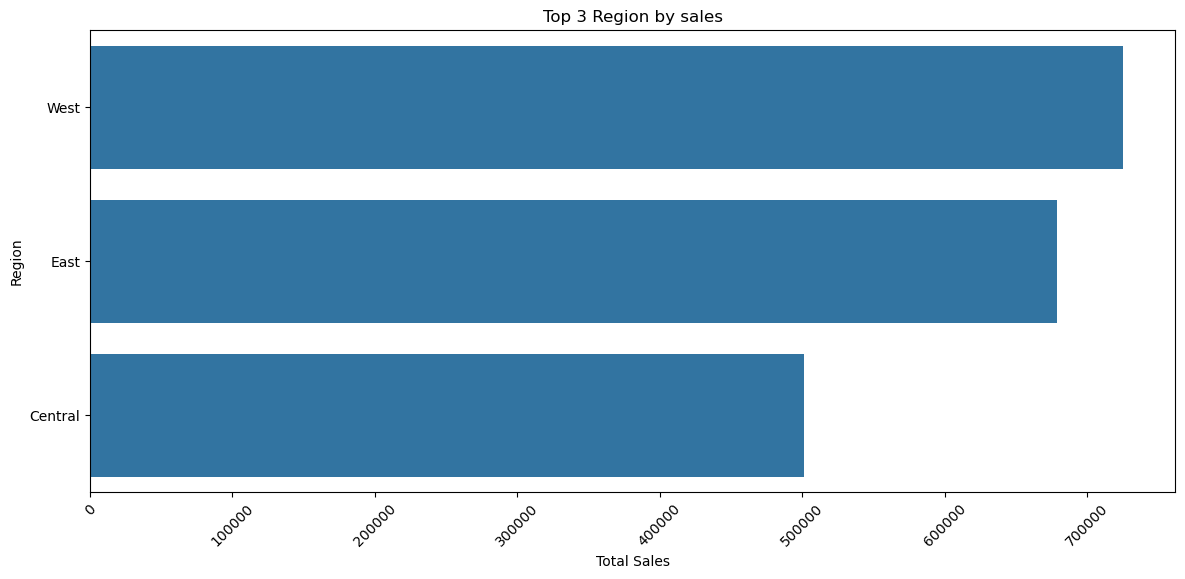

In [51]:
#visualization profit margin
plt.figure(figsize=(14,6))
top_Region=df.groupby('Region')['Sales'].sum().nlargest(3)
sns.barplot(x=top_Region.values,y=top_Region.index)

plt.xticks(rotation=45)
plt.title('Top 3 Region by sales')
plt.xlabel('Total Sales')
plt.ylabel('Region')
plt.show()
